<a href="https://colab.research.google.com/github/Abel-Kurian/Ai-internship/blob/main/Day4_Image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

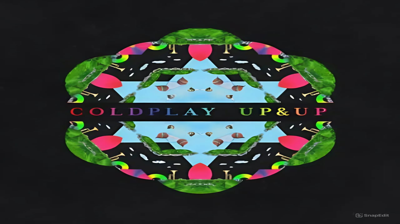

In [6]:
from PIL import Image

im = Image.open("/content/new.jpeg")

im_resize = im.resize((400,224))



im_resize

In [7]:
import numpy as np

im_array = np.array(im)/255.0  #uniform ranges

im_array

array([[[0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        ...,
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078]],

       [[0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        ...,
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078]],

       [[0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        ...,
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078]],

       ...,

       [[0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0.09411765, 0.10196078],
        [0.09411765, 0

array([[25, 25, 25, ..., 25, 25, 25],
       [25, 25, 25, ..., 25, 25, 25],
       [26, 26, 26, ..., 25, 25, 25],
       ...,
       [25, 25, 25, ..., 28, 28, 28],
       [25, 25, 25, ..., 27, 27, 27],
       [25, 25, 25, ..., 25, 25, 25]], dtype=uint8)
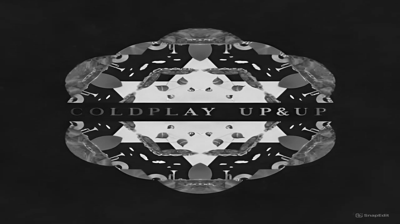

In [8]:
from cv2 import cvtColor, COLOR_BGR2GRAY

im_ar = np.array(im_resize)
im_gray = cvtColor(im_ar, COLOR_BGR2GRAY)

im_gray

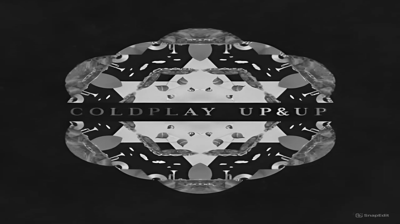

In [9]:
from PIL import ImageEnhance,ImageOps
import os

flipped = ImageOps.mirror(im_resize)
rotated = im_resize.rotate(30)
enha = ImageEnhance.Brightness(im_resize)
brighter = enha.enhance(1.5)
contrast=ImageEnhance.Contrast(im_resize)
contrasted = contrast.enhance(1.5)
grayscale = ImageOps.grayscale(im_resize)

grayscale


In [10]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/new.jpeg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


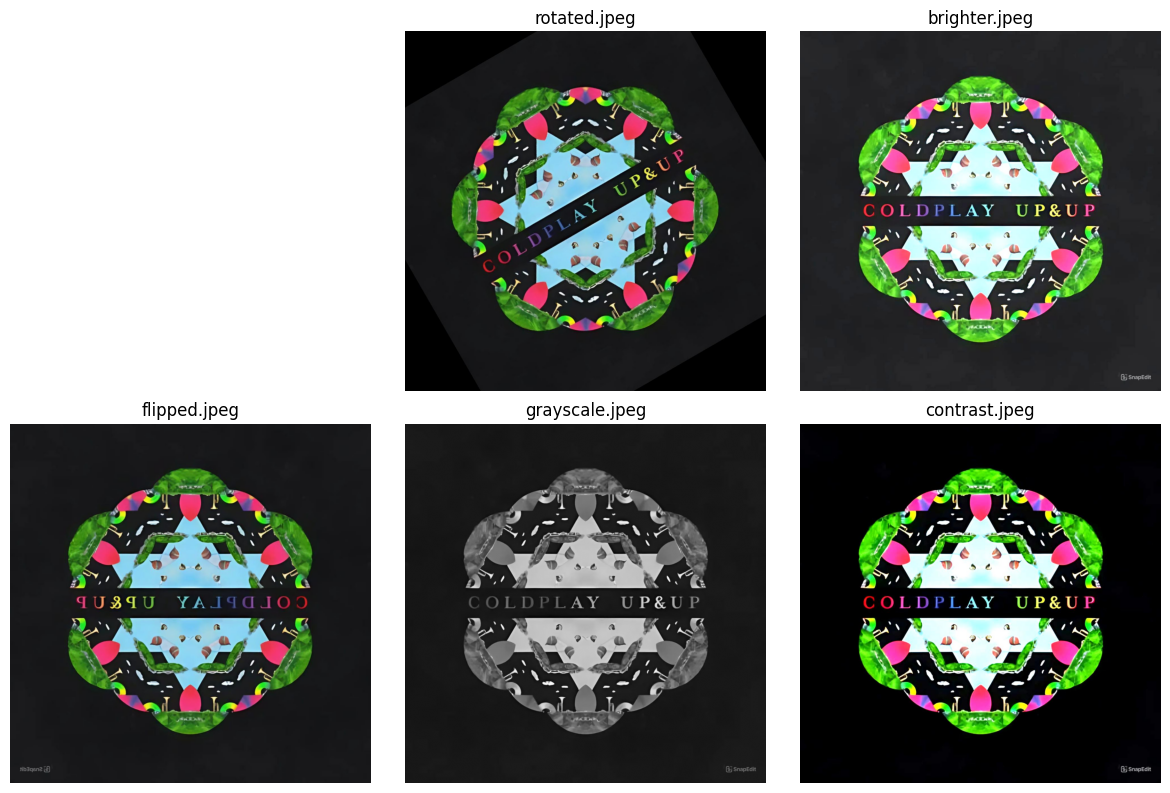

In [11]:
import matplotlib.pyplot as plt

augmented_images = os.listdir(augmented_dir)

plt.figure(figsize=(12, 8))

for i, image_name in enumerate(augmented_images, 1):
    image_path = os.path.join(augmented_dir, image_name)
    image = Image.open(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(image,cmap="gray" if image_name.endswith("grayscale.jpeg") else None)
    plt.title(image_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 421


In [13]:
im1 = Image.open("/content/extracted_images/iris-setosa/iris-01ab65973fd487a6cee4c5af1551c42b264eec5abab46bffd7c307ffef647e11.jpg")
im2 = Image.open("/content/extracted_images/iris-setosa/iris-0797945218a97d6e5251b4758a2ba1b418cbd52ce4ef46a3239e4b939bd9807b.jpg")
im3 = Image.open("/content/extracted_images/iris-versicolour/iris-009322547cb81cbb4dbc63c298304a2df8ea617191651d4cbd50b7a5bbba8a6a.jpg")
im4 = Image.open("/content/extracted_images/iris-versicolour/iris-0337d20a3b7273aa0ddaa7d6afb57a37a759b060e4401871db3cefaa6adc068d.jpg")
im5 = Image.open("/content/extracted_images/iris-virginica/iris-08c7a0e53ee1de193062d7bf86a21adec67b9115fd6099f1b2d2ee728a936002.jpg")

im_resize1 = im1.resize((224,224))
im_resize2 = im2.resize((224,224))
im_resize3 = im3.resize((224,224))
im_resize4 = im4.resize((224,224))
im_resize5 = im5.resize((224,224))




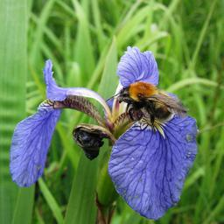

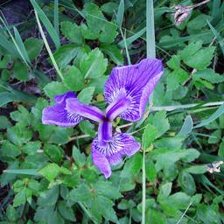

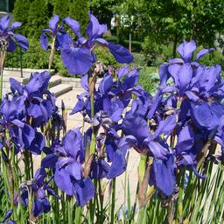

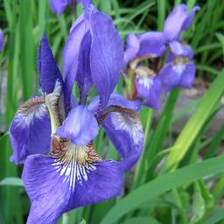

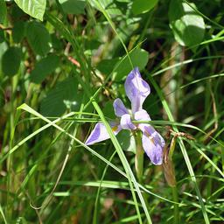

In [15]:
from PIL import Image

im1 = Image.open("/content/extracted_images/iris-setosa/iris-01ab65973fd487a6cee4c5af1551c42b264eec5abab46bffd7c307ffef647e11.jpg")
im2 = Image.open("/content/extracted_images/iris-setosa/iris-0797945218a97d6e5251b4758a2ba1b418cbd52ce4ef46a3239e4b939bd9807b.jpg")
im3 = Image.open("/content/extracted_images/iris-versicolour/iris-009322547cb81cbb4dbc63c298304a2df8ea617191651d4cbd50b7a5bbba8a6a.jpg")
im4 = Image.open("/content/extracted_images/iris-versicolour/iris-0337d20a3b7273aa0ddaa7d6afb57a37a759b060e4401871db3cefaa6adc068d.jpg")
im5 = Image.open("/content/extracted_images/iris-virginica/iris-08c7a0e53ee1de193062d7bf86a21adec67b9115fd6099f1b2d2ee728a936002.jpg")



In [17]:
from PIL import Image
import os

extracted_images_root = "extracted_images"

# Iterate through all subdirectories and files in the extracted_images folder
for root, dirs, files in os.walk(extracted_images_root):
    for file in files:
        # Check if the file is an image
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_path = os.path.join(root, file)
            try:
                # Open the image
                img = Image.open(image_path)
                # Resize the image
                img_resized = img.resize((224, 224))
                # Save the resized image, overwriting the original
                img_resized.save(image_path)
            except Exception as e:
                print(f"Error processing {image_path}: {e}")

print("All images in 'extracted_images' have been resized to (224,224).")

All images in 'extracted_images' have been resized to (224,224).


In [18]:
import pandas as pd

image_data = []
for i, img in enumerate(images):
    height, width, channels = img.shape
    image_data.append({
        'Image_Index': i,
        'Height': height,
        'Width': width,
        'Channels': channels
    })

image_properties_df = pd.DataFrame(image_data)
display(image_properties_df.head())

,Image_Index,Height,Width,Channels
0,0,256,256,3
1,1,256,256,3
2,2,256,256,3
3,3,256,256,3
4,4,256,256,3


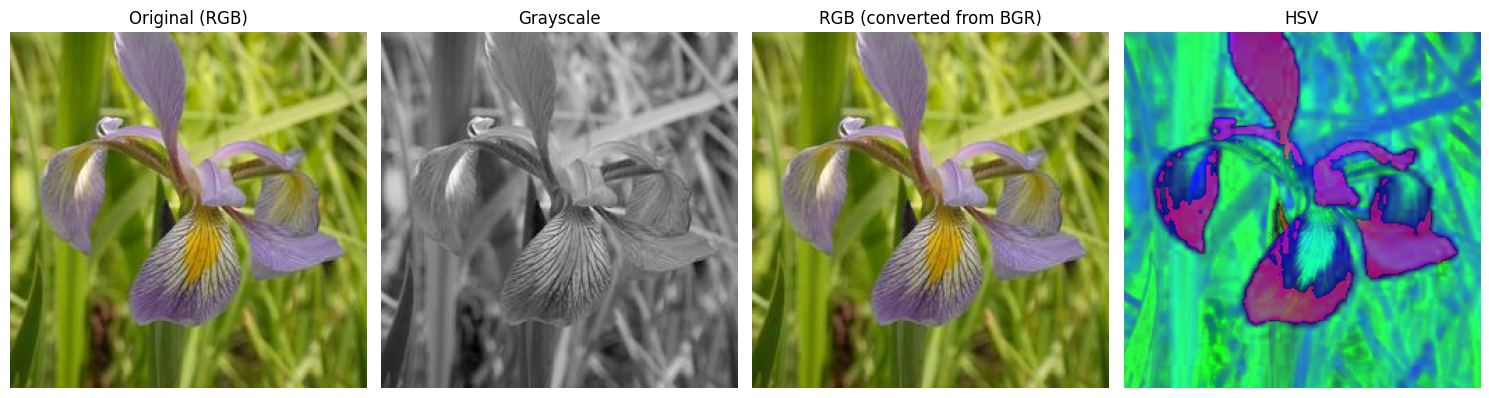

In [19]:
import cv2
import matplotlib.pyplot as plt

# Using the first image from the loaded list for demonstration
demo_image = images[0]

# Convert to Grayscale
gray_image = cv2.cvtColor(demo_image, cv2.COLOR_BGR2GRAY)

# Convert to RGB (OpenCV loads images as BGR by default)
rgb_image = cv2.cvtColor(demo_image, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv_image = cv2.cvtColor(demo_image, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(demo_image, cv2.COLOR_BGR2RGB))
plt.title('Original (RGB)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(rgb_image)
plt.title('RGB (converted from BGR)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(hsv_image)
plt.title('HSV')
plt.axis('off')

plt.tight_layout()
plt.show()

Normalized RGB image shape: (256, 256, 3)
Normalized RGB image min/max pixel values: 0.0 1.0
Normalized Grayscale image shape: (256, 256)
Normalized Grayscale image min/max pixel values: 0.050980393 0.99607843


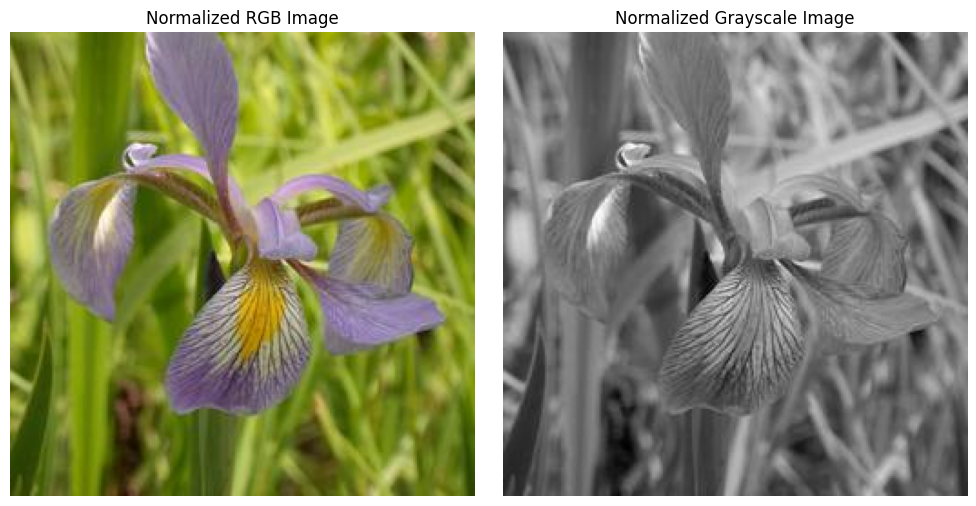

In [20]:
# Normalize RGB image
normalized_rgb_image = rgb_image.astype('float32') / 255.0

# Normalize Grayscale image
normalized_gray_image = gray_image.astype('float32') / 255.0

print("Normalized RGB image shape:", normalized_rgb_image.shape)
print("Normalized RGB image min/max pixel values:", normalized_rgb_image.min(), normalized_rgb_image.max())

print("Normalized Grayscale image shape:", normalized_gray_image.shape)
print("Normalized Grayscale image min/max pixel values:", normalized_gray_image.min(), normalized_gray_image.max())


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(normalized_rgb_image)
plt.title('Normalized RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(normalized_gray_image, cmap='gray')
plt.title('Normalized Grayscale Image')
plt.axis('off')

plt.tight_layout()
plt.show()

Shape of preprocessed image: (224, 224, 3)
Min pixel value: 0.0
Max pixel value: 1.0


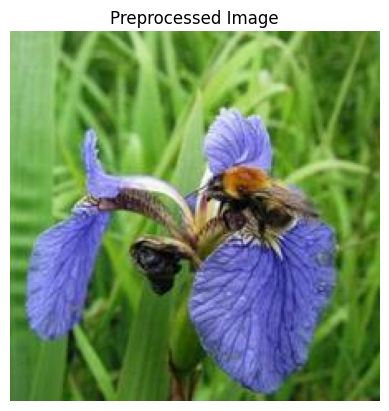

In [21]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image(image_path, target_size=(224, 224)):

    img_pil = Image.open(image_path).convert('RGB')
    img_cv2 = np.array(img_pil) # PIL's RGB is equivalent to OpenCV's BGR if channels were swapped, but here we just convert to array

    # Resize the image
    resized_image = cv2.resize(img_cv2, target_size)



    # Normalize pixel values to 0-1
    normalized_image = resized_image.astype('float32') / 255.0

    return normalized_image

# Demonstrate the function with one of the extracted images
demo_image_path = "/content/extracted_images/iris-setosa/iris-01ab65973fd487a6cee4c5af1551c42b264eec5abab46bffd7c307ffef647e11.jpg"
preprocessed_img = preprocess_image(demo_image_path)

print("Shape of preprocessed image:", preprocessed_img.shape)
print("Min pixel value:", preprocessed_img.min())
print("Max pixel value:", preprocessed_img.max())

import matplotlib.pyplot as plt
plt.imshow(preprocessed_img)
plt.title("Preprocessed Image")
plt.axis('off')
plt.show()